In [1]:
import os
import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2
import numpy as np

In [2]:
def display_images_with_annotations(image_paths, annotation_paths):
    fig, axs = plt.subplots(2, 2, figsize=(10, 10))
    
    for ax, img_path, ann_path in zip(axs.ravel(), image_paths, annotation_paths):
        # Load image using OpenCV and convert it from BGR to RGB color space
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        img_h, img_w, _ = image.shape
        
        ax.imshow(image)
        ax.axis('off')  # Turn off the axes

        # Open the annotation file and process each line
        with open(ann_path, 'r') as file:
            for line in file:
                parts = line.strip().split()
                category_id = int(parts[0])
                color = tuple(np.random.rand(3))  # Generate a random RGB color
                polygon = [float(coord) for coord in parts[1:]]
                polygon = [coord * img_w if i % 2 == 0 else coord * img_h for i, coord in enumerate(polygon)]
                polygon = [(polygon[i], polygon[i+1]) for i in range(0, len(polygon), 2)]
                patch = patches.Polygon(polygon, closed=True, edgecolor=color, fill=False)
                ax.add_patch(patch)

    plt.tight_layout()
    plt.show()

In [7]:
# Get all image files
image_dir = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\YOLOv8x Dataset\train\images"
annotation_dir = r"E:\404_Found\H&E Stained Histological Nucleus Instancve Segmentation by YOLOv8x\Dataset\YOLOv8x Dataset\train\labels"
all_image_files = [f for f in os.listdir(image_dir) if f.endswith('.png')]
random_image_files = random.sample(all_image_files, 4)

In [8]:
# Get corresponding annotation files
image_paths = [os.path.join(image_dir, f) for f in random_image_files]
annotation_paths = [os.path.join(annotation_dir, f.replace('.png', '.txt')) for f in random_image_files]

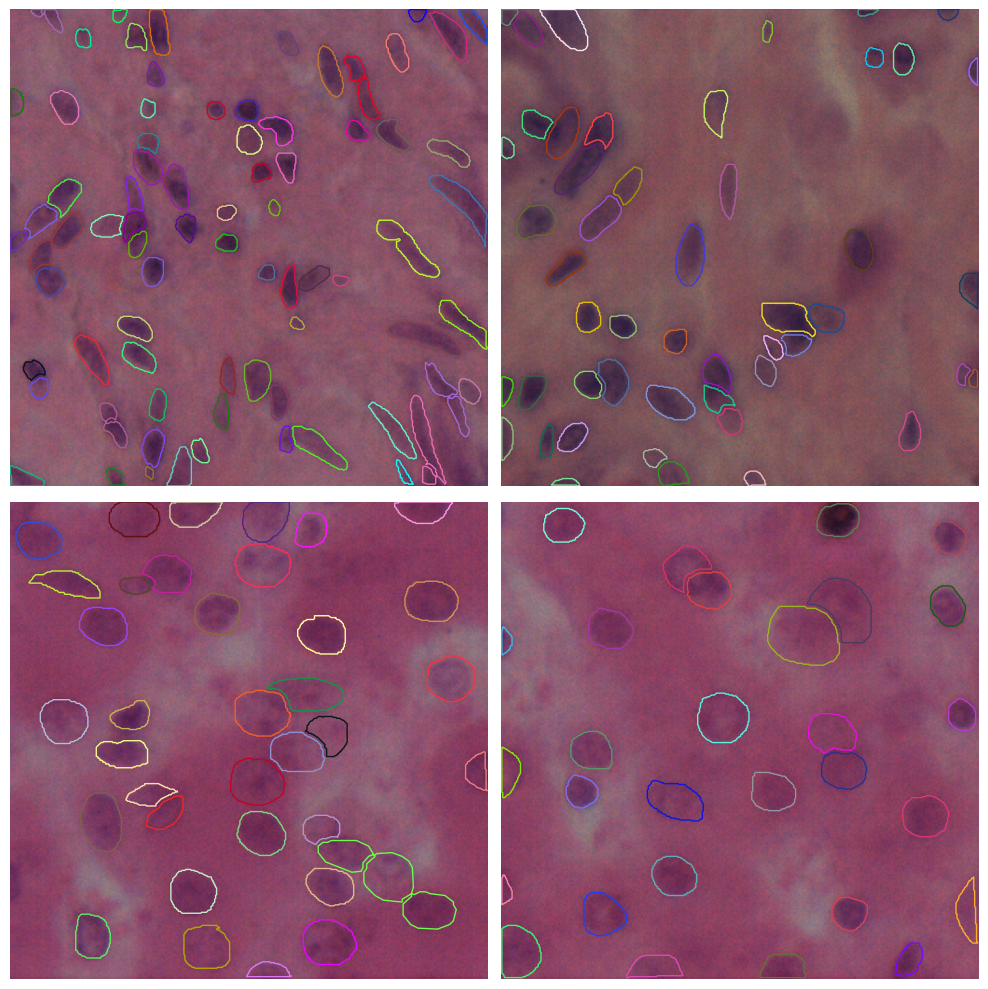

In [9]:
display_images_with_annotations(image_paths, annotation_paths)